## Discretization

Discretization is the process of transforming continuous variables into discrete variables by creating a set of contiguous intervals that span the range of the variable's values. Discretization is also called **binning**, where bin is an alternative name for interval.


### Discretization helps handle outliers and may improve the value spread in skewed variables

Discretization helps handle outliers by placing these values into the lower or higher intervals, together with the remaining inlier values of the distribution. Thus, these outlier observations no longer differ from the rest of the values at the tails of the distribution, as they are now all together in the same interval or bucket. In addition, by creating appropriate bins or intervals, discretization can help spread the values of a skewed variable across a set of bins with an equal number of observations.


### Discretization approaches

There are several approaches to transform continuous variables into discrete ones. Discretization methods fall into 2 categories: **supervised and unsupervised**. Unsupervised methods do not use any information other than the variable distribution to create the contiguous bins in which the values will be placed. Supervised methods typically use target information in order to create the bins or intervals.


####  Unsupervised discretization methods

- Equal width discretisation
- Equal frequency discretization
- K-means discretization

#### Supervised discretization methods

- Discretization using decision trees


## Equal width discretization

Equal width discretization divides the scope of possible values into N bins of the same width. The width is determined by the range of values in the variable and the number of bins we wish to use to divide the variable:

width = (max value - min value) / N

where N is the number of bins or intervals.

For example, if the values of the variable vary between 0 and 100, we create 5 bins like this: width = (100-0) / 5 = 20. The bins thus are 0-20, 20-40, 40-60, 80-100. The first and final bins (0-20 and 80-100) can be expanded to accommodate outliers (that is, values under 0 or greater than 100 would be placed in those bins as well).

There is no rule of thumb to define N; that is something to determine experimentally.

## Equal frequency discretization

Equal frequency discretization divides the scope of possible values of the variable into N bins, where each bin carries the same amount of observations. This is particularly useful for skewed variables, as it spreads the observations over the different bins equally. We find the interval boundaries by determining the quantiles.

Equal frequency discretization using quantiles consists of dividing the continuous variable into N quantiles, where N to be defined by the user.

Equal frequency binning is straightforward to implement, and by spreading the values of the observations more evenly, it may help boost the algorithm's performance. This arbitrary binning may also disrupt the relationship with the target.

## Discretization with k-means clustering

This discretization method consists of applying k-means clustering to the continuous variable.

Briefly, the algorithm works as follows:

- 1) Initialization: random creation of K centers
- 2) Each data point is associated with the closest center
- 3) Each center position is re-computed as the center of its associated points

Steps 2 and 3 are repeated until convergence is reached. The algorithm minimizes the pairwise squared deviations of points within the same cluster.

More details about k-means are [here](https://en.wikipedia.org/wiki/K-means_clustering)

Nice blog with graphical explanation of k-means [here](https://towardsdatascience.com/how-does-k-means-clustering-in-machine-learning-work-fdaaaf5acfa0)

Note that the user needs to define the number of clusters.

## Discretization with Decision Trees

Discretization with decision trees consists of using a decision tree to identify the optimal bins. When a decision tree makes a decision, it assigns an observation to one of its end leaves. Therefore, any decision tree will generate a discrete output, whose values are the predictions at each of its n leaves.

How to do discretization with trees?

- 1) Train a decision tree of limited depth (2, 3  or 4) using the variable we want to discretize and the target.
- 2) Replace the values by the output returned by the tree.


### Advantages

- The output returned by the decision tree is monotonically related to the target.
- The tree end nodes, or bins, in the discretized variable show decreased entropy, that is, the observations within each bin are more similar among themselves than to those of other bins.

### Limitations

- Prone over-fitting
- More importantly, some tuning of the tree parameters is needed to obtain the optimal number of splits (e.g., tree depth, minimum number of samples in one partition, maximum number of partitions, and a minimum information gain). This it can be time consuming.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
#Dowload The Datasets
!wget -O /content/titanic.csv "https://drive.google.com/uc?export=download&id=1G4J51PvGEc52d0TZ0KQYi1CsS5absHSZ"
!wget -O /content/loan.csv "https://drive.google.com/uc?export=download&id=1_XhwYC-0-pSMZ5FW0aFn0zziernj5nmS"
!wget -O /content/houseprice.csv "https://drive.google.com/uc?export=download&id=1smKY0l_s5NNR29uJavLh1I59RBCb09yy"
!wget -O /content/bag_of_words.csv "https://drive.google.com/uc?export=download&id=1sIOgEH-ZBxQ4anOle-fDXpYw6VN8UmGD"

--2025-04-04 13:57:00--  https://drive.google.com/uc?export=download&id=1G4J51PvGEc52d0TZ0KQYi1CsS5absHSZ
Resolving drive.google.com (drive.google.com)... 142.251.2.101, 142.251.2.139, 142.251.2.138, ...
Connecting to drive.google.com (drive.google.com)|142.251.2.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1G4J51PvGEc52d0TZ0KQYi1CsS5absHSZ&export=download [following]
--2025-04-04 13:57:00--  https://drive.usercontent.google.com/download?id=1G4J51PvGEc52d0TZ0KQYi1CsS5absHSZ&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.2.132, 2607:f8b0:4023:c0d::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.2.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 104076 (102K) [application/octet-stream]
Saving to: ‘/content/titanic.csv’

/content/titanic.cs 100%[===================>] 101.64K  --.-KB/s 

In [3]:
# load the numerical variables of the Titanic Dataset

data = pd.read_csv('/content/titanic.csv', usecols=['age', 'fare', 'survived'])

data.head()

,survived,age,fare
0,1,29.0000,211.3375
1,1,0.9167,151.5500
2,0,2.0000,151.5500
3,0,30.0000,151.5500
4,0,25.0000,151.5500


In [4]:
# Let's separate into train and test set

X_train, X_test, y_train, y_test = train_test_split(
    data[['age', 'fare']],
    data['survived'],
    test_size=0.3,
    random_state=0)

X_train.shape, X_test.shape

((916, 2), (393, 2))

The variables Age and fare contain missing data, which I will fill by extracting a random sample of the variable.

In [5]:
def impute_na(data, variable):

    df = data.copy()

    # random sampling
    df[variable + '_random'] = df[variable]

    # extract the random sample to fill the na
    random_sample = X_train[variable].dropna().sample(
        df[variable].isnull().sum(), random_state=0)

    # pandas needs to have the same index in order to merge datasets
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(), variable + '_random'] = random_sample

    return df[variable + '_random']

In [6]:
# replace NA in both train and test sets

X_train['age'] = impute_na(X_train, 'age')
X_test['age'] = impute_na(X_test, 'age')

X_train['fare'] = impute_na(X_train, 'fare')
X_test['fare'] = impute_na(X_test, 'fare')

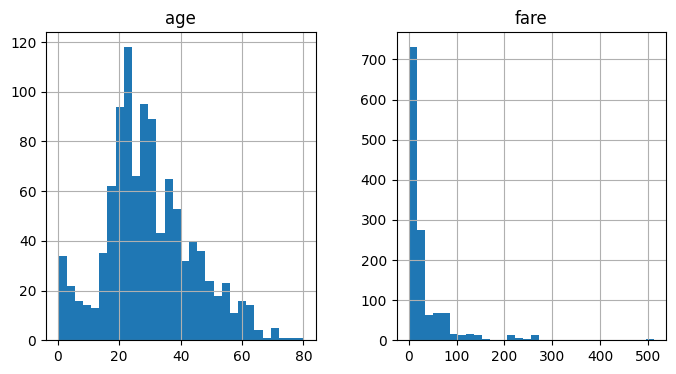

In [7]:
# let's explore the distribution of age

data[['age', 'fare']].hist(bins=30, figsize=(8,4))
plt.show()

## Equal width discretisation with pandas

In [8]:
# let's make labels to label the different bins

labels = ['bin_' + str(i) for i in range(1, 9)]

labels

['bin_1', 'bin_2', 'bin_3', 'bin_4', 'bin_5', 'bin_6', 'bin_7', 'bin_8']

In [9]:
# create binned age / discretise age

# create one column with labels
X_train['Age_disc_labels'], bins = pd.cut(
    x=X_train['age'], bins=8, labels=labels, retbins=True, precision=0, include_lowest=True)

# and one with bin boundaries
X_train['Age_disc'] = pd.cut(
    x=X_train['age'], bins=8, precision=0, include_lowest=True)

X_train.head(10)

,age,fare,Age_disc_labels,Age_disc
501,13.0,19.5000,bin_2,"(9.0, 19.0]"
588,4.0,23.0000,bin_1,"(-0.9, 9.0]"
402,30.0,13.8583,bin_4,"(28.0, 37.0]"
1193,40.5,7.7250,bin_5,"(37.0, 46.0]"
686,22.0,7.7250,bin_3,"(19.0, 28.0]"
971,39.0,7.8792,bin_5,"(37.0, 46.0]"
117,30.0,56.9292,bin_4,"(28.0, 37.0]"
540,2.0,26.0000,bin_1,"(-0.9, 9.0]"
294,49.0,110.8833,bin_6,"(46.0, 56.0]"
261,35.0,26.2875,bin_4,"(28.0, 37.0]"


In [10]:
# the limits of the intervals

bins

array([ 0.0928667,  9.3958625, 18.625025 , 27.8541875, 37.08335  ,
       46.3125125, 55.541675 , 64.7708375, 74.       ])

We can see in the above output how by discretising using equal width, we placed each Age observation within one interval / bin. For example, age=13 was placed in the 9-19 interval, whereas age 30 was placed into the 28-37 interval.

When performing equal width discretisation, we guarantee that the intervals are all of the same length, however there won't necessarily be the same number of observations in each of the intervals. See below:

In [11]:
# number of observations per interval

X_train.groupby('Age_disc', observed=False)['age'].count()

,age
Age_disc,
"(-0.9, 9.0]",64
"(9.0, 19.0]",90
"(19.0, 28.0]",277
"(28.0, 37.0]",243
"(37.0, 46.0]",114
"(46.0, 56.0]",77
"(56.0, 65.0]",40
"(65.0, 74.0]",11


Text(0, 0.5, 'Number of observations per bin')

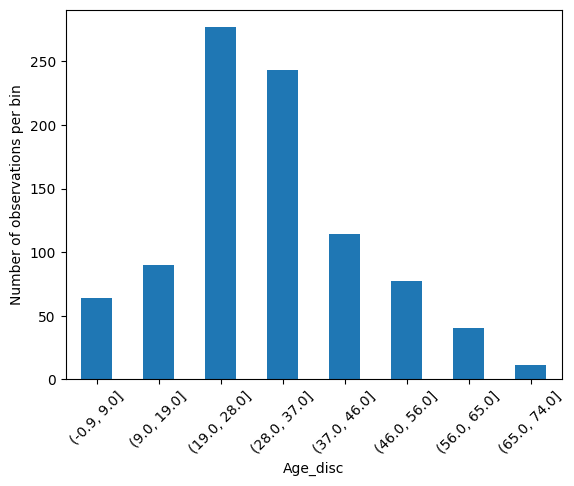

In [12]:
X_train.groupby('Age_disc', observed=False)['age'].count().plot.bar()
plt.xticks(rotation=45)
plt.ylabel('Number of observations per bin')

The majority of people on the Titanic were between 18-36 years of age.

Now, we can discretise Age in the test set, using the **same interval boundaries** that we calculated for the train set:

In [13]:
# discretize the test set
# note that we use the bin limits learned from the train set

X_test['Age_disc_labels'] = pd.cut(
    x=X_test['age'], bins=bins, labels=labels, precision=0, include_lowest=True)

X_test['Age_disc'] = pd.cut(x=X_test['age'], bins=bins, precision=0, include_lowest=True)

X_test.head()

,age,fare,Age_disc_labels,Age_disc
1139,38.0,7.8958,bin_5,"(37.0, 46.0]"
533,21.0,21.0000,bin_3,"(19.0, 28.0]"
459,42.0,27.0000,bin_5,"(37.0, 46.0]"
1150,3.0,14.5000,bin_1,"(-0.9, 9.0]"
393,25.0,31.5000,bin_3,"(19.0, 28.0]"


Text(0, 0.5, 'Number of observations per bin')

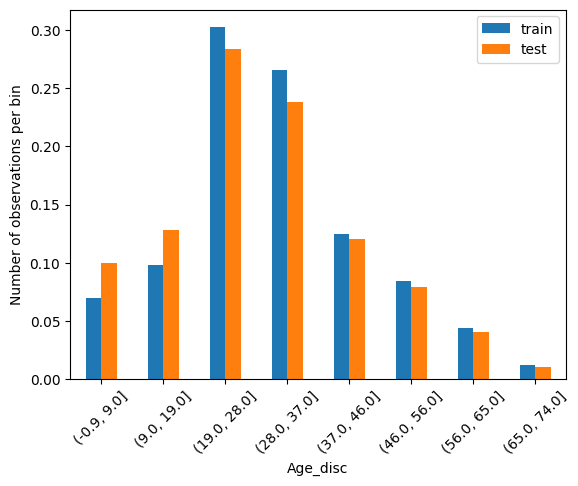

In [14]:
# if the distributions in train and test set are similar, we should expect similar propotion of
# observations in the different intervals in the train and test set
# let's see that below

t1 = X_train['Age_disc'].value_counts(normalize=True).sort_index()
t2 = X_test['Age_disc'].value_counts(normalize=True).sort_index()

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['train', 'test']
tmp.plot.bar()
plt.xticks(rotation=45)
plt.ylabel('Number of observations per bin')

## Equal frequency discretization

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [16]:
# load the numerical variables of the Titanic Dataset

data = pd.read_csv('/content/titanic.csv', usecols=['age', 'fare', 'survived'])

data.head()

,survived,age,fare
0,1,29.0000,211.3375
1,1,0.9167,151.5500
2,0,2.0000,151.5500
3,0,30.0000,151.5500
4,0,25.0000,151.5500


In [17]:
# Let's separate into train and test set

X_train, X_test, y_train, y_test = train_test_split(
    data[['age', 'fare']],
    data['survived'],
    test_size=0.3,
    random_state=0)

X_train.shape, X_test.shape

((916, 2), (393, 2))

The variables Age and Fare contain missing data, that I will fill by extracting a random sample of the variable.

In [18]:
def impute_na(data, variable):
    # function to fill NA with a random sample

    df = data.copy()

    # random sampling
    df[variable+'_random'] = df[variable]

    # extract the random sample to fill the na
    random_sample = X_train[variable].dropna().sample(
        df[variable].isnull().sum(), random_state=0)

    # pandas needs to have the same index in order to merge datasets
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(), variable+'_random'] = random_sample

    return df[variable+'_random']

In [19]:
# replace NA in both train and test sets

X_train['age'] = # COMPLETE THIS CODE
X_test['age'] = # COMPLETE THIS CODE

X_train['fare'] = # COMPLETE THIS CODE
X_test['fare'] = # COMPLETE THIS CODE

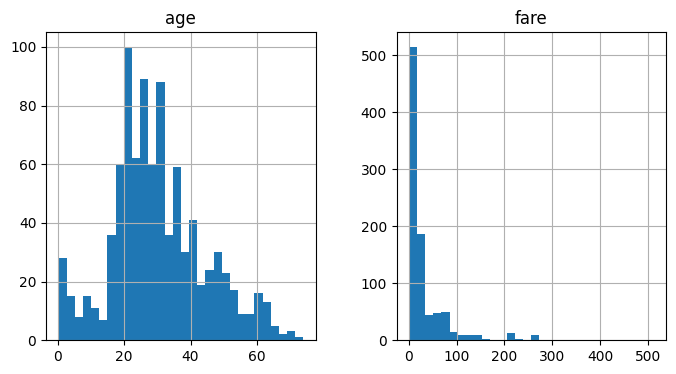

In [20]:
# let's explore the distribution of age

X_train[['age', 'fare']].hist(bins=30, figsize=(8,4))
plt.show()

In [21]:
# let's use pandas qcut (quantile cut) and I indicate that
# we want 10 bins.

# retbins = True indicates that I want to capture the limits
# of each interval (so I can then use them to cut the test set)

Age_disccretised, intervals = pd.qcut(
    X_train['age'], 10, labels=None, retbins=True, precision=3, duplicates='raise')

pd.concat([Age_disccretised, X_train['age']], axis=1).head(10)

,age,age
501,"(0.166, 16.0]",13.0
588,"(0.166, 16.0]",4.0
402,"(28.0, 31.0]",30.0
1193,"(36.0, 42.0]",40.5
686,"(20.0, 22.0]",22.0
971,"(36.0, 42.0]",39.0
117,"(28.0, 31.0]",30.0
540,"(0.166, 16.0]",2.0
294,"(42.0, 50.0]",49.0
261,"(31.0, 36.0]",35.0


We can see in the above output how by discretising using quantiles, we placed each Age observation within one interval. For example, age 30 was placed in the 28-31 interval, whereas age 49 was placed into the 42-50 interval.

Note how the interval widths are different.

We can visualise the interval cut points below:

In [22]:
intervals

array([ 0.1667, 16.    , 20.    , 22.    , 25.    , 28.    , 31.    ,
       36.    , 42.    , 50.    , 74.    ])

And because we generated the bins using the quantile cut method, we should have roughly the same amount of observations per bin. See below.

In [23]:
# roughly the same number of passengers per interval

Age_disccretised.value_counts()

,count
age,
"(0.166, 16.0]",106
"(31.0, 36.0]",106
"(16.0, 20.0]",92
"(22.0, 25.0]",92
"(25.0, 28.0]",92
"(28.0, 31.0]",90
"(42.0, 50.0]",90
"(36.0, 42.0]",85
"(20.0, 22.0]",82


In [24]:
# we can also add labels instead of having the interval boundaries, to the bins, as follows:

labels = ['Q'+str(i) for i in range(1,11)]
labels

['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']

In [25]:
Age_disccretised, intervals = pd.qcut(X_train['age'], 10, labels=labels,
                                      retbins=True,
                                      precision=3, duplicates='raise')

Age_disccretised.head()

,age
501,Q1
588,Q1
402,Q6
1193,Q8
686,Q3


In [26]:
# to apply the intervals to the test set, we need to extend
# the limits of the outer bins to -inf and +inf, so that if
# in the test set, there are smaller or bigger values than the
# minimum or maximum values in the train set, they can be
# accomodated in the outer intervals.
# Otherwise, they will be replaced by NaN.

# Prepend/Append infinities to accommodate outliers
intervals[0] = float("-inf")
intervals[len(intervals) - 1] = float("inf")

intervals

array([-inf,  16.,  20.,  22.,  25.,  28.,  31.,  36.,  42.,  50.,  inf])

In [27]:
# to transform the test set:
# we use pandas cut method (instead of qcut) and
# pass the quantile edges calculated in the training set

X_test['Age_disc_label'] = pd.cut(x = X_test['age'], bins=intervals, labels=labels)
X_test['Age_disc'] = pd.cut(x = X_test['age'], bins=intervals)

X_test.head(10)

,age,fare,Age_disc_label,Age_disc
1139,38.0,7.8958,Q8,"(36.0, 42.0]"
533,21.0,21.0000,Q3,"(20.0, 22.0]"
459,42.0,27.0000,Q8,"(36.0, 42.0]"
1150,3.0,14.5000,Q1,"(-inf, 16.0]"
393,25.0,31.5000,Q4,"(22.0, 25.0]"
1189,4.0,16.7000,Q1,"(-inf, 16.0]"
5,48.0,26.5500,Q9,"(42.0, 50.0]"
231,52.0,30.5000,Q10,"(50.0, inf]"
330,57.0,13.0000,Q10,"(50.0, inf]"
887,31.0,8.1125,Q6,"(28.0, 31.0]"


In [28]:
X_test['Age_disc_label'].isnull().sum()

np.int64(0)

<Axes: xlabel='Age_disc'>

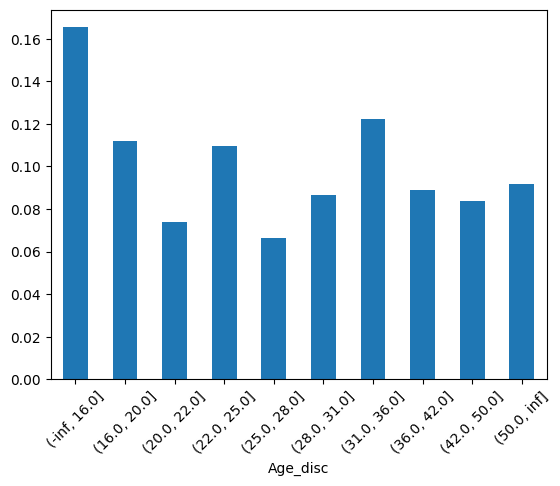

In [29]:
# let's check that we have equal frequency (equal number of observations per bin)
# COMPLETE THIS CODE

If some intervals have less observations, which can happen with skewed distributions, to make the value spread more homogeneous, we could try using less intervals.

## Domain knowledge discretization

[Feature Engineering for Machine Learning Course](https://www.trainindata.com/p/feature-engineering-for-machine-learning)

Frequently, when engineering variables in a business setting, the business experts determine the intervals in which they think the variable should be divided so that it makes sense for the business. Typical examples include the discretization of variables like age and income.


Income, for example, is usually capped at a certain maximum value, and all incomes above that value fall into the last bucket. As per age, it is usually divided into certain groups according to the business need; for example, divisions into 0-21 (for under-aged), 20-30 (for young adults), 30-40, 40-60, and > 60 (for retired or close to) are frequent.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
# load the Titanic Dataset

data = pd.read_csv('/content/titanic.csv', usecols=['age', 'survived'])

data.head()

,survived,age
0,1,29.0000
1,1,0.9167
2,0,2.0000
3,0,30.0000
4,0,25.0000


The variable Age contains missing data, that I will fill by extracting a random sample of the variable.

In [32]:
def impute_na(data, variable):
    df = data.copy()

    # random sampling
    df[variable+'_random'] = df[variable]

    # extract the random sample to fill the na
    random_sample = data[variable].dropna().sample(
        df[variable].isnull().sum(), random_state=0)

    # pandas needs to have the same index in order to merge datasets
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(), variable+'_random'] = random_sample

    return df[variable+'_random']

In [33]:
# let's fill the missing data
data['age'] = impute_na(data, 'age')

In [34]:
# let's divide Age into the buckets that we described in the intro cell
# of this notebook

# bucket boundaries
# COMPLETE THIS CODE

# bucket labels
# COMPLETE THIS CODE

# discretisation
# COMPLETE THIS CODE

,survived,age,Age_buckets_labels,Age_buckets
0,1,29.0000,20-40,"(20.0, 40.0]"
1,1,0.9167,0-20,"(-0.001, 20.0]"
2,0,2.0000,0-20,"(-0.001, 20.0]"
3,0,30.0000,20-40,"(20.0, 40.0]"
4,0,25.0000,20-40,"(20.0, 40.0]"


In [35]:
data.tail()

,survived,age,Age_buckets_labels,Age_buckets
1304,0,14.5,0-20,"(-0.001, 20.0]"
1305,0,39.0,20-40,"(20.0, 40.0]"
1306,0,26.5,20-40,"(20.0, 40.0]"
1307,0,27.0,20-40,"(20.0, 40.0]"
1308,0,29.0,20-40,"(20.0, 40.0]"


Above we can observe the buckets into which each Age observation was placed. For example, age 14 was placed into the 0-20 bucket.

Let's explore the number of observations and survival rate per bucket after this arbitrary discretisation method.

<Axes: xlabel='Age_buckets_labels'>

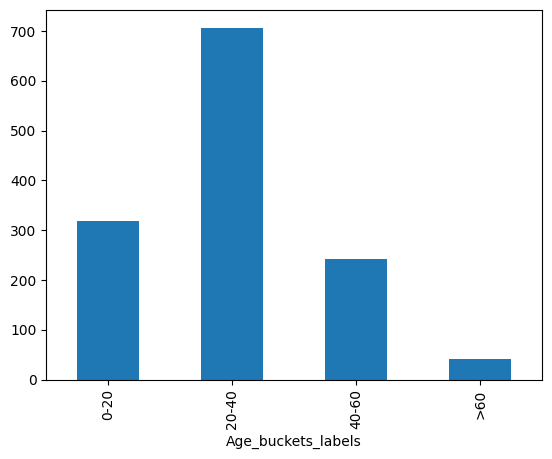

In [36]:
# number of passengers per age bucket

# COMPLETE THIS CODE

<Axes: xlabel='Age_buckets_labels'>

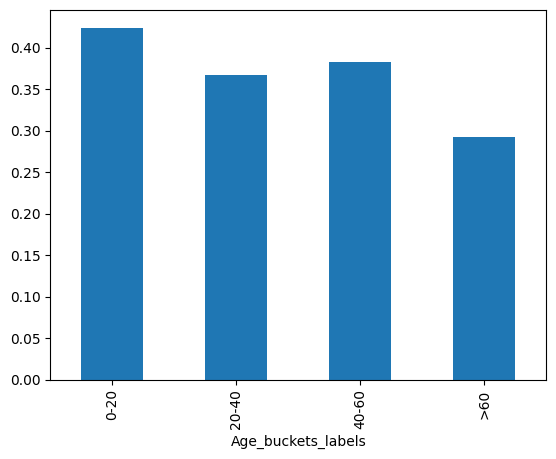

In [37]:
# survival rate per age bucket

# COMPLETE THIS CODE

## Peer to peer

Let's explore discretisation using domain knowledge in a different business scenario. I will use the loan book from the peer to peer lending company. This dataset contains information on loans given to people, and the financial characteristics of those people as well as the loan performance.

In [38]:
# I will load only the income declared by the borrower for the demonstration

data = pd.read_csv('/content/loan.csv', usecols=['income'])

data.head()

,income
0,84600.0
1,102000.0
2,69840.0
3,100386.0
4,95040.0


In [39]:
data['income'].describe()

,income
count,1.000000e+04
mean,7.157229e+04
std,5.286105e+04
min,0.000000e+00
25%,4.365000e+04
50%,6.045000e+04
75%,8.536000e+04
max,2.185000e+06


<Axes: >

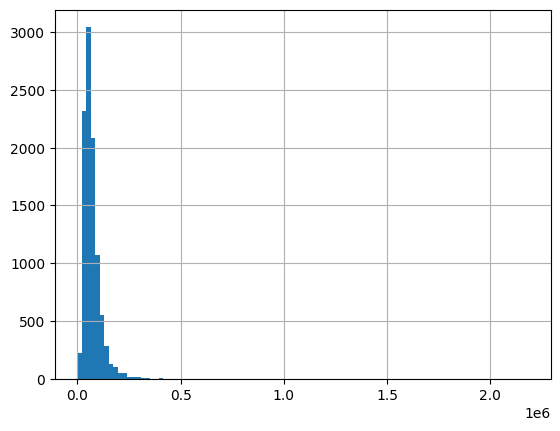

In [40]:
# let's inspect the distribution of Incomes

data['income'].hist(bins=100)

<Axes: >

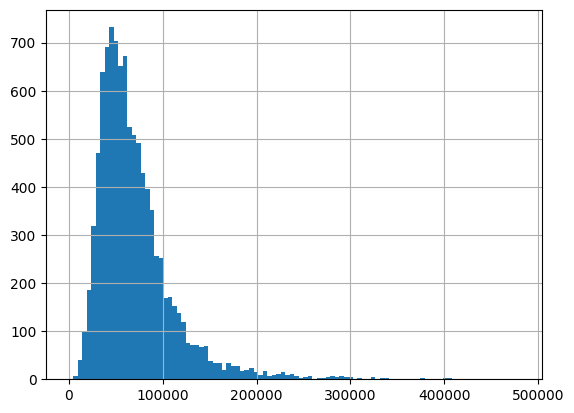

In [41]:
# and now let's look at the lower incomes in more detail

data[data['income']<500000]['income'].hist(bins=100)

We can see that the majority of the population earns below 150,000. So we may want to make a cap there.

In [42]:
# and now let's divide into arbitrary buckets, assuming that these make business sense

# bucket interval
# COMPLETE THIS CODE

# bucket labels
# COMPLETE THIS CODE

# discretisation
# COMPLETE THIS CODE

,income,Income_buckets
0,84600.0,65-90k
1,102000.0,90-150k
2,69840.0,65-90k
3,100386.0,90-150k
4,95040.0,90-150k


In [43]:
data.tail()

,income,Income_buckets
9995,98000.0,90-150k
9996,36270.0,0-45k
9997,52250.0,45-65k
9998,80040.0,65-90k
9999,72000.0,65-90k


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '0-45k'),
  Text(1, 0, '45-65k'),
  Text(2, 0, '65-90k'),
  Text(3, 0, '90-150k'),
  Text(4, 0, '>150k')])

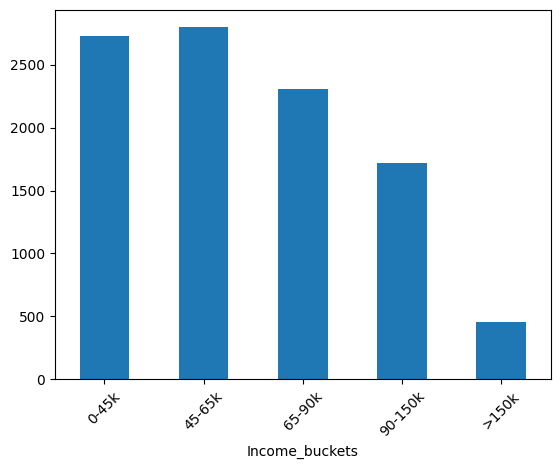

In [44]:
# COMPLETE THIS CODE

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '0-45k'),
  Text(1, 0, '45-65k'),
  Text(2, 0, '65-90k'),
  Text(3, 0, '90-150k'),
  Text(4, 0, '>150k')])

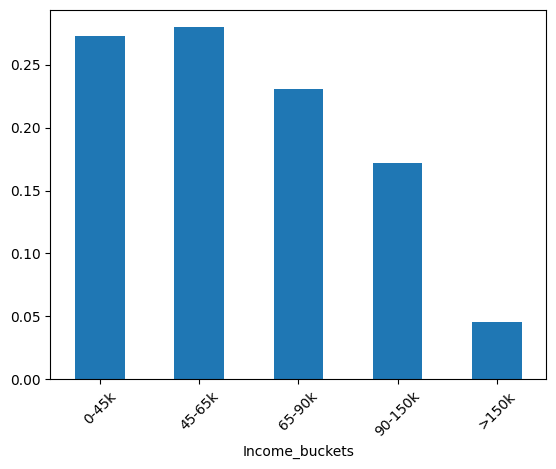

In [45]:
# COMPLETE THIS CODE

## Discretization with k-means clustering

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

In [47]:
# load the numerical variables of the Titanic Dataset

data = pd.read_csv('/content/titanic.csv',
                   usecols=['age', 'fare', 'survived'])

data.head()

,survived,age,fare
0,1,29.0000,211.3375
1,1,0.9167,151.5500
2,0,2.0000,151.5500
3,0,30.0000,151.5500
4,0,25.0000,151.5500


In [48]:
# Let's separate into train and test set

X_train, X_test, y_train, y_test = train_test_split(
    data[['age', 'fare']],
    data['survived'],
    test_size=0.3,
    random_state=0)

X_train.shape, X_test.shape

((916, 2), (393, 2))

The variables Age and Fare contain missing data, that I will fill by extracting a random sample of the variable.

In [49]:
def impute_na(data, variable):
    # function to fill NA with a random sample

    df = data.copy()

    # random sampling
    df[variable+'_random'] = df[variable]

    # extract the random sample to fill the na
    random_sample = X_train[variable].dropna().sample(
        df[variable].isnull().sum(), random_state=0)

    # pandas needs to have the same index in order to merge datasets
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(), variable+'_random'] = random_sample

    return df[variable+'_random']

In [50]:
# replace NA in both train and test sets

# COMPLETE THIS CODE

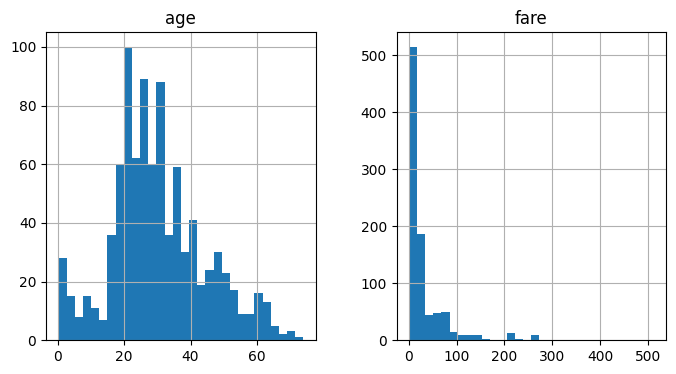

In [51]:
# let's explore the distribution of age

X_train[['age', 'fare']].hist(bins=30, figsize=(8,4))
plt.show()

In [52]:
disc = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans', subsample=None)

disc.set_output(transform="pandas")

disc.fit(X_train[['age', 'fare']])

KBinsDiscretizer(encode='ordinal', n_bins=4, strategy='kmeans', subsample=None)

In [53]:
disc.bin_edges_

array([array([ 0.1667    , 19.35059866, 34.06303553, 50.22640292, 74.        ]),
       array([  0.        ,  48.38317511, 155.62486898, 371.03119259,
              512.3292    ])                                         ],
      dtype=object)

In [54]:
train_t = # COMPLETE THIS CODE
test_t = # COMPLETE THIS CODE

train_t.head()

,age,fare
501,0.0,0.0
588,0.0,0.0
402,1.0,0.0
1193,2.0,0.0
686,1.0,0.0


Text(0, 0.5, 'Number of observations per bin')

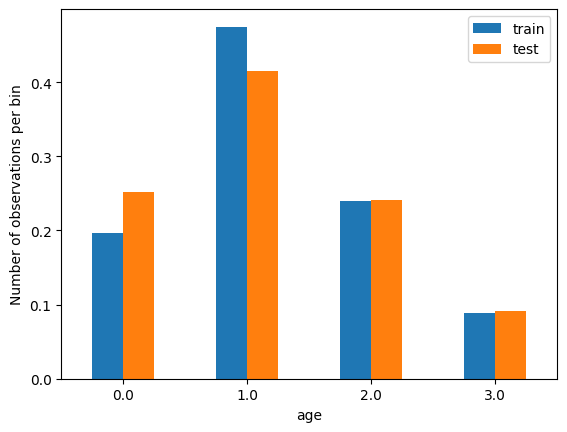

In [55]:
# COMPLETE THIS CODE

Text(0, 0.5, 'Number of observations per bin')

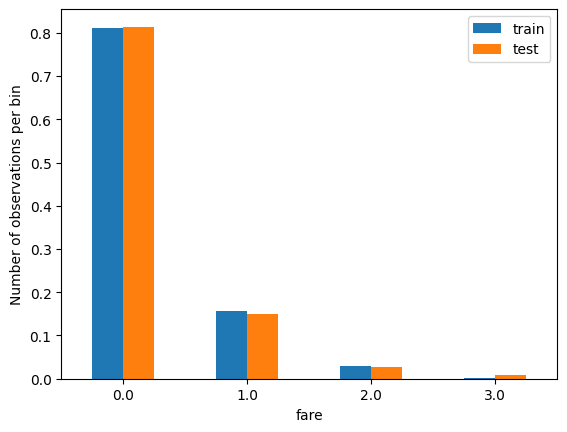

In [56]:
# COMPLETE THIS CODE

## Discretization with Decision Trees


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

In [58]:
# load the numerical variables of the Titanic Dataset

data = pd.read_csv(
    '/content/titanic.csv',
    usecols=['age', 'fare', 'survived'])


data.head()

,survived,age,fare
0,1,29.0000,211.3375
1,1,0.9167,151.5500
2,0,2.0000,151.5500
3,0,30.0000,151.5500
4,0,25.0000,151.5500


In [59]:
# Let's separate into train and test set

X_train, X_test, y_train, y_test = train_test_split(
    data[['age', 'fare']],
    data['survived'],
    test_size=0.3,
    random_state=0)

X_train.shape, X_test.shape

((916, 2), (393, 2))

The variables Age and Fare contain missing data, that I will fill by extracting a random sample of the variable.

In [60]:
def impute_na(data, variable):
    df = data.copy()

    # random sampling
    df[variable+'_random'] = df[variable]
    # extract the random sample to fill the na
    random_sample = X_train[variable].dropna().sample(df[variable].isnull().sum(), random_state=0)
    # pandas needs to have the same index in order to merge datasets
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(), variable+'_random'] = random_sample

    return df[variable+'_random']

In [61]:
# replace NA in both train and test sets

# COMPLETE THIS CODE

In [62]:
# example: build Classification tree using Age to predict Survived

tree_model = DecisionTreeClassifier(max_depth=2)

tree_model.fit(X_train['age'].to_frame(), y_train)

DecisionTreeClassifier(max_depth=2)

In [63]:
# "replace values with predictions

X_train['age_prob'] = np.round(
    tree_model.predict_proba(X_train['age'].to_frame())[:, 1], 3)

X_test['age_prob'] = # COMPLETE THIS CODE

X_train.head(10)

,age,fare,age_prob
501,13.0,19.5000,0.611
588,4.0,23.0000,0.458
402,30.0,13.8583,0.393
1193,40.5,7.7250,0.393
686,22.0,7.7250,0.393
971,39.0,7.8792,0.393
117,30.0,56.9292,0.393
540,2.0,26.0000,0.458
294,49.0,110.8833,0.393
261,35.0,26.2875,0.393


In [64]:
# let's explore how many end points the tree created

X_train['age_prob'].unique()

array([0.611, 0.458, 0.393, 0.287])

Text(0, 0.5, 'Survived')

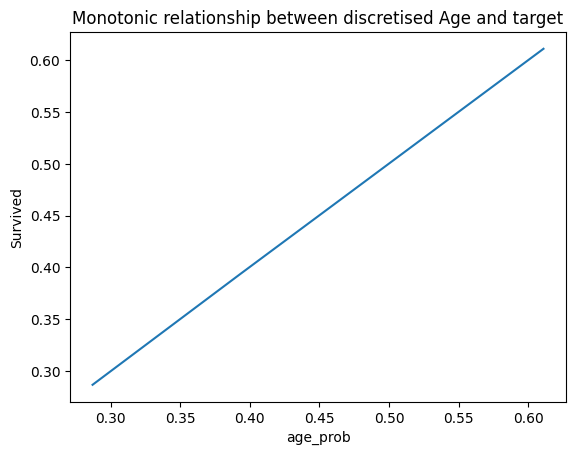

In [65]:
# relationship with target

y_train.groupby(X_train['age_prob']).mean().plot()
plt.title('Monotonic relationship between discretised Age and target')
plt.ylabel('Survived')

Text(0, 0.5, 'Survived')

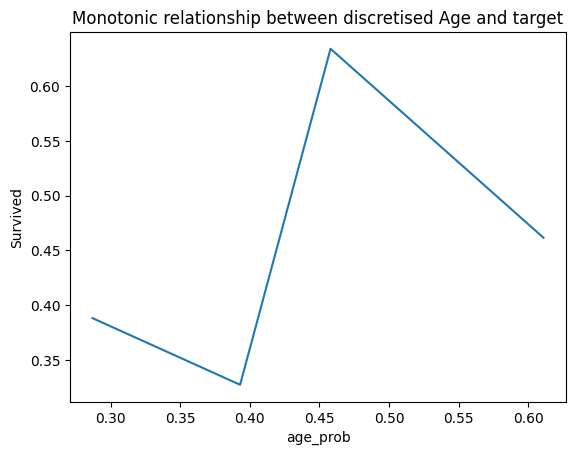

In [66]:
y_test.groupby(X_test['age_prob']).mean().plot()
plt.title('Monotonic relationship between discretised Age and target')
plt.ylabel('Survived')

<Axes: xlabel='age_prob'>

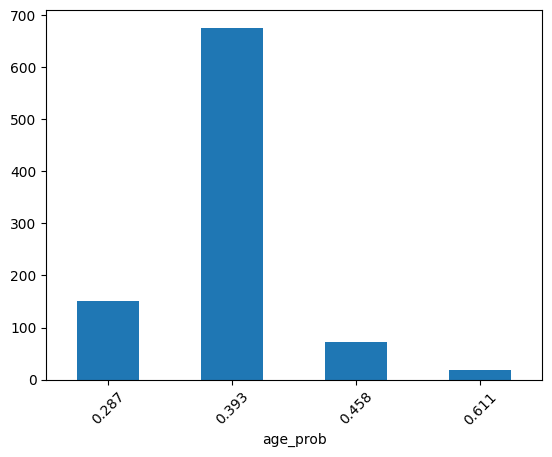

In [67]:
# number of passengers per node / bin

X_train['age_prob'].value_counts().sort_index().plot.bar(rot=45)

<Axes: xlabel='age_prob'>

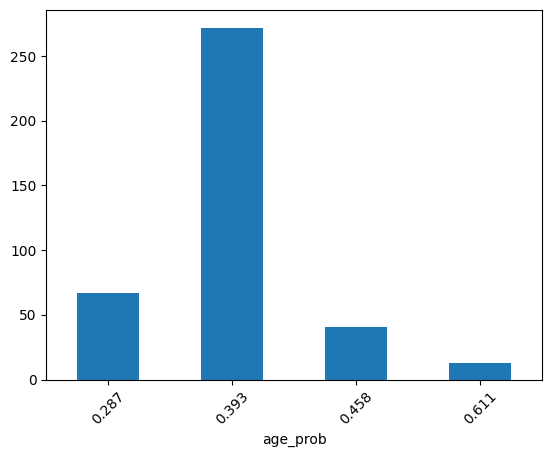

In [68]:
X_test['age_prob'].value_counts().sort_index().plot.bar(rot=45)

In [69]:
# let's see the Age limits buckets generated by the tree
# by capturing the minimum and maximum age per each probability bucket,
# we get an idea of the bucket cut-offs

tmp = pd.concat( [X_train.groupby(['age_prob'])['age'].min(),
            X_train.groupby(['age_prob'])['age'].max()], axis=1)

tmp.columns = ["min", "max"]

tmp

,min,max
age_prob,,
0.287,16.0000,21.0
0.393,22.0000,74.0
0.458,0.1667,11.5
0.611,12.0000,15.0


In [70]:
# get inteval edges

bins = list(X_train.groupby(['age_prob'])['age'].min().sort_values().values)

bins

[np.float64(0.1667), np.float64(12.0), np.float64(16.0), np.float64(22.0)]

In [71]:
# expand to plus and minus inf

bins[0] = -np.inf
bins.append(np.inf)

bins

[-inf, np.float64(12.0), np.float64(16.0), np.float64(22.0), inf]

## Tree visualization

In [72]:
import graphviz
from sklearn.tree import export_graphviz

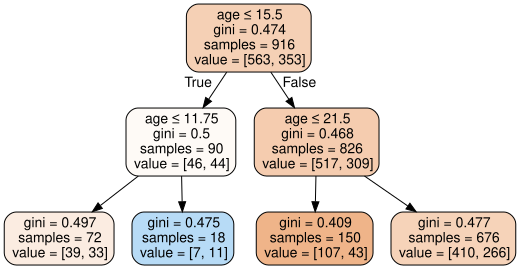

In [73]:
dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=["age"],
    filled=True, rounded=True,
    special_characters=True)

graph = graphviz.Source(dot_data)

graph

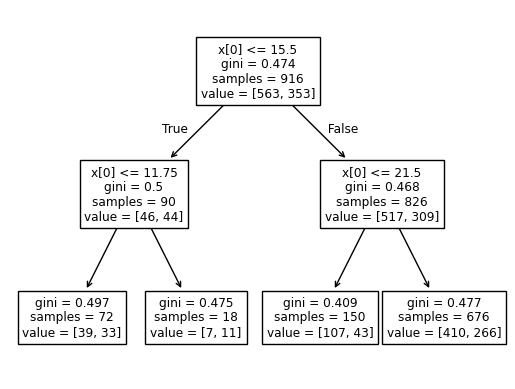

In [74]:
# alternative way of visualizing

from sklearn.tree import plot_tree

plot_tree(tree_model)
plt.show()

## Optimizing the decision tree

There are a number of parameters that we could optimize to obtain the best split using decision trees.

I will optimize the tree depth for this demonstration. But remember that we could also optimize the remaining parameters of the decision tree.

Visit [sklearn website](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier) to see which other parameters can be optimized.

In [75]:
from sklearn.model_selection import GridSearchCV

In [76]:
parameters = {'max_depth':[1, 2, 3, 4]}

clf = GridSearchCV(
    tree_model,
    parameters,
    cv=3,
    refit=True, # so that it returns a fitted model
)

clf.fit(X_train["age"].to_frame(), y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(max_depth=2),
             param_grid={'max_depth': [1, 2, 3, 4]})

In [77]:
# the results

pd.DataFrame(clf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003931,0.000764,0.002679,0.000086,1,{'max_depth': 1},0.614379,0.593443,0.573770,0.593864,0.016581,3
1,0.003278,0.000068,0.002437,0.000033,2,{'max_depth': 2},0.614379,0.606557,0.590164,0.603700,0.010090,1
2,0.003393,0.000155,0.003717,0.001066,3,{'max_depth': 3},0.601307,0.590164,0.573770,0.588414,0.011310,4
3,0.003284,0.000023,0.002505,0.000151,4,{'max_depth': 4},0.611111,0.609836,0.577049,0.599332,0.015765,2


In [78]:
# the most interesting part of the resutls

pd.DataFrame(clf.cv_results_)[['params', 'mean_test_score', 'std_test_score']]

,params,mean_test_score,std_test_score
0,{'max_depth': 1},0.593864,0.016581
1,{'max_depth': 2},0.603700,0.010090
2,{'max_depth': 3},0.588414,0.011310
3,{'max_depth': 4},0.599332,0.015765


In [79]:
# the best depth

clf.best_params_

{'max_depth': 2}

In [80]:
# the trained decision tree

clf.best_estimator_

DecisionTreeClassifier(max_depth=2)

In [81]:
# "discretize" the variable

X_train['age_prob'] = np.round(
    clf.best_estimator_.predict_proba(X_train['age'].to_frame())[:, 1], 3)


X_test['age_prob'] = # COMPLETE THIS CODE

Text(0, 0.5, 'Survived')

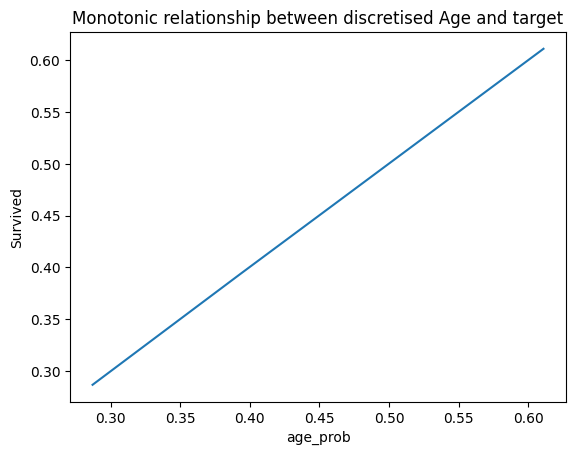

In [82]:
# relationship with target

# COMPLETE THIS CODE

Text(0, 0.5, 'Survived')

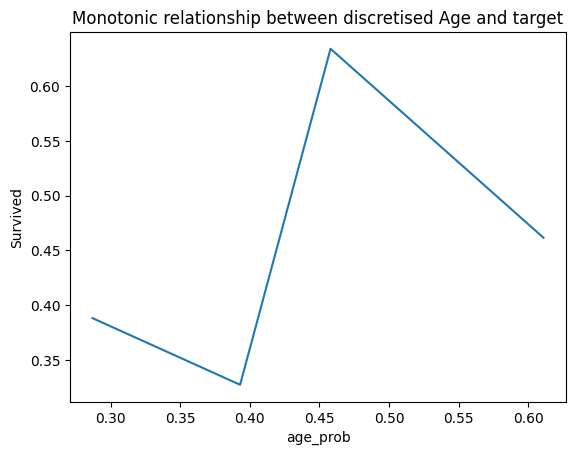

In [83]:
# COMPLETE THIS CODE

Now the monotonic relationship is not totally maintained in the test. Probably because there are few samples in the upper buckets:

<Axes: xlabel='age_prob'>

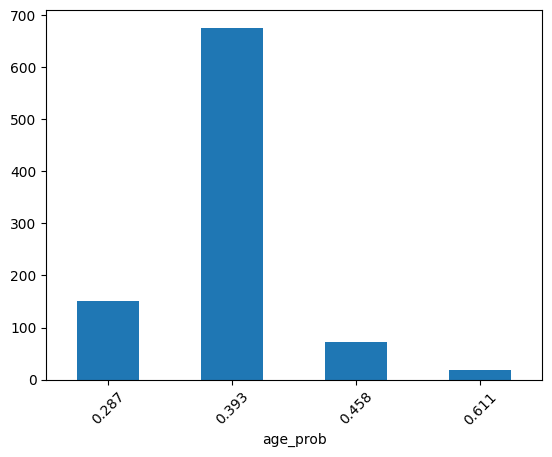

In [84]:
# number of passengers per probabilistic bucket / bin

X_train['age_prob'].value_counts().sort_index().plot.bar(rot=45)

<Axes: xlabel='age_prob'>

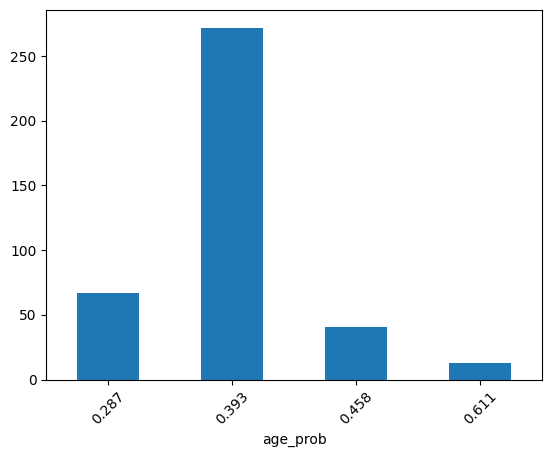

In [85]:
# number of passengers per probabilistic bucket / bin

X_test['age_prob'].value_counts().sort_index().plot.bar(rot=45)

We could try and optimise the decision tree further to see if we can keep the monotonic relationship. Or alternatively, directly test the model performance with these engineered features and see if they add any value.

In [86]:
# get the interval limists

bins = list(X_train.groupby(['age_prob'])['age'].min().sort_values().values)

bins[0] = -np.inf
bins.append(np.inf)

bins

[-inf, np.float64(12.0), np.float64(16.0), np.float64(22.0), inf]

## Binarization

[Feature Engineering for Machine Learning Course](https://www.trainindata.com/p/feature-engineering-for-machine-learning)

We will use a new dataset that contains words. Check the folder 02-Datasets and the notebook `donwload-prepare-store-enron-data.ipynb` to get hold of the data.

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Binarizer

In [88]:
# load the bag of words dataset

data = pd.read_csv("/content/bag_of_words.csv")

data.head()

,advice,cab,decker,etis,eurobond,halligan,keen,pvr,refundable,soda
0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


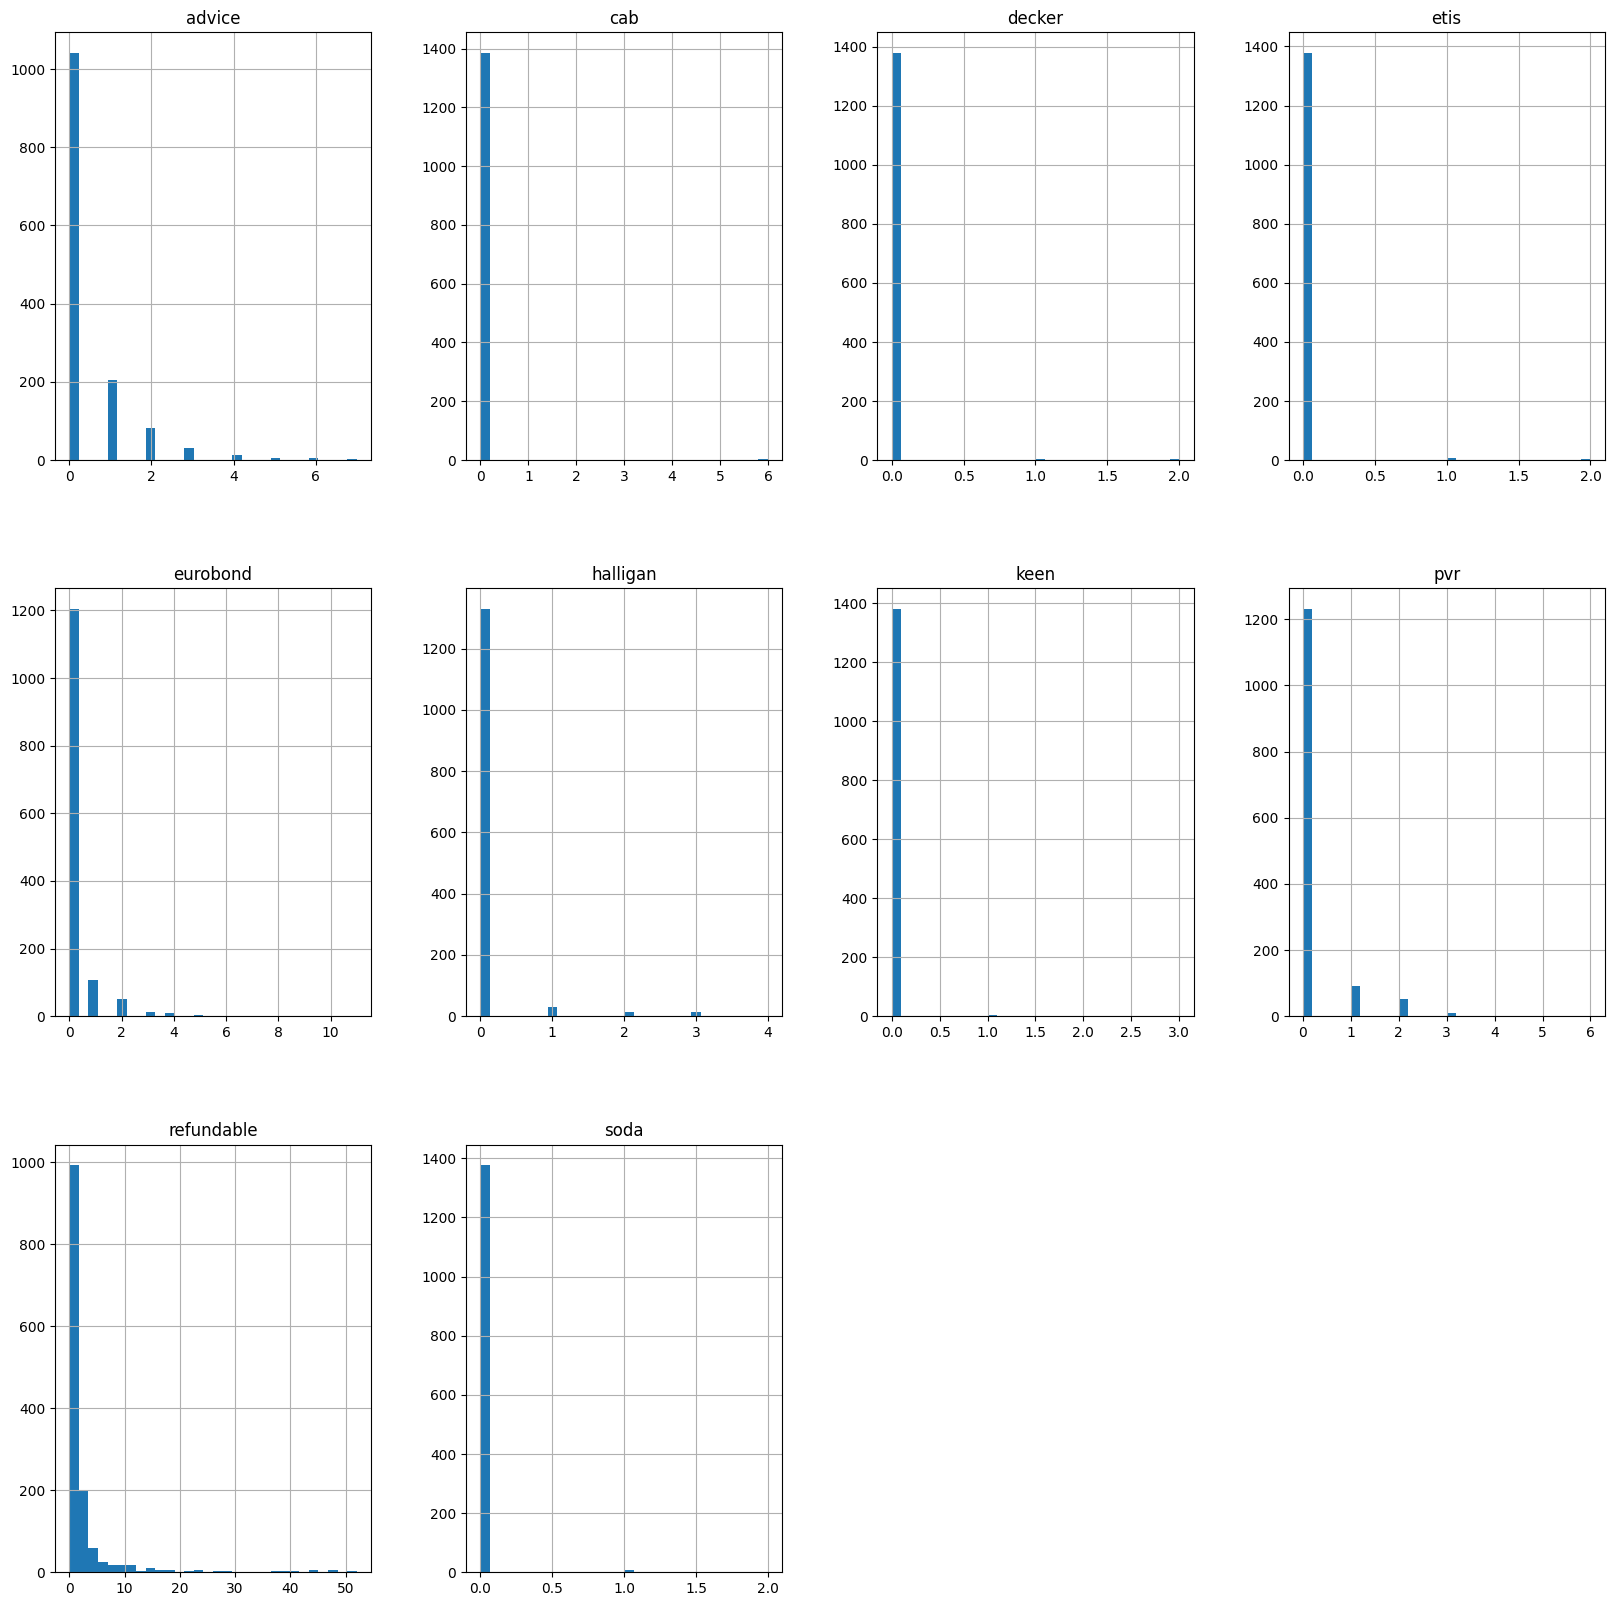

In [89]:
# Plot histograms to inspect variable distributions

data.hist(bins=30, figsize=(20, 20), layout=(3, 4))
plt.show()

In [90]:
data.nunique()

,0
advice,8
cab,2
decker,3
etis,3
eurobond,7
halligan,5
keen,4
pvr,7
refundable,35
soda,3


In [91]:
data.describe()

,advice,cab,decker,etis,eurobond,halligan,keen,pvr,refundable,soda
count,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000
mean,0.427954,0.008646,0.007925,0.007925,0.219020,0.072767,0.009366,0.177954,2.336455,0.007925
std,0.940093,0.227675,0.110426,0.103691,0.695758,0.394309,0.144294,0.581526,6.151411,0.096488
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
max,7.000000,6.000000,2.000000,2.000000,11.000000,4.000000,3.000000,6.000000,52.000000,2.000000


In [92]:
# set up a Binarizer:

binarizer = Binarizer(threshold=0).set_output(transform="pandas")

In [93]:
# fit to data

data_t = binarizer.fit_transform(data)

In [94]:
data_t.describe()

,advice,cab,decker,etis,eurobond,halligan,keen,pvr,refundable,soda
count,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000
mean,0.249280,0.001441,0.005764,0.006484,0.131844,0.041787,0.005043,0.112392,0.505764,0.007205
std,0.432752,0.037946,0.075727,0.080292,0.338443,0.200174,0.070862,0.315962,0.500147,0.084604
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


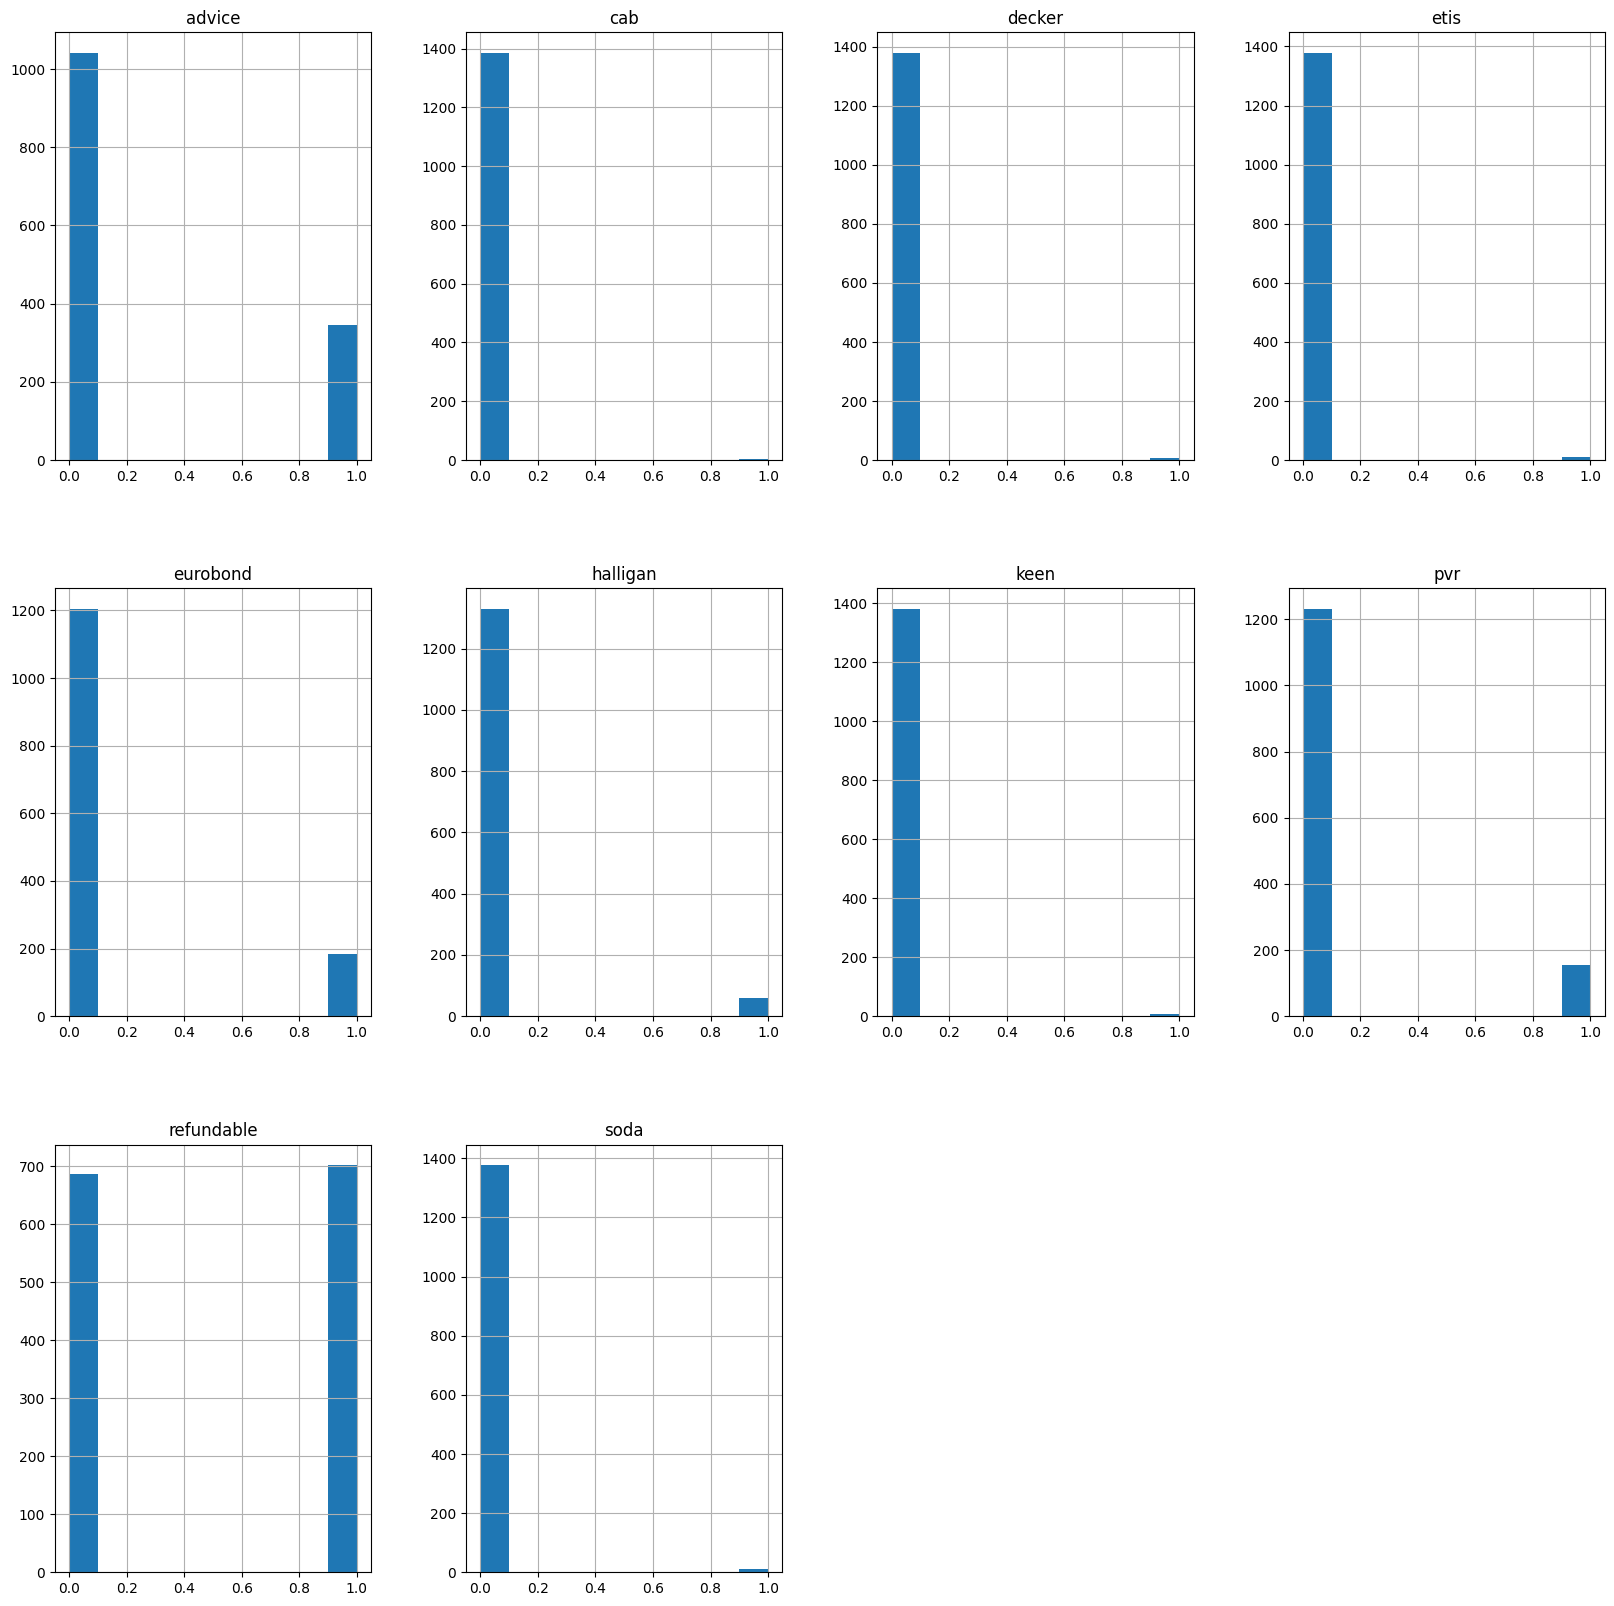

In [95]:
data_t.hist(figsize=(20, 20), layout=(3, 4))
plt.show()

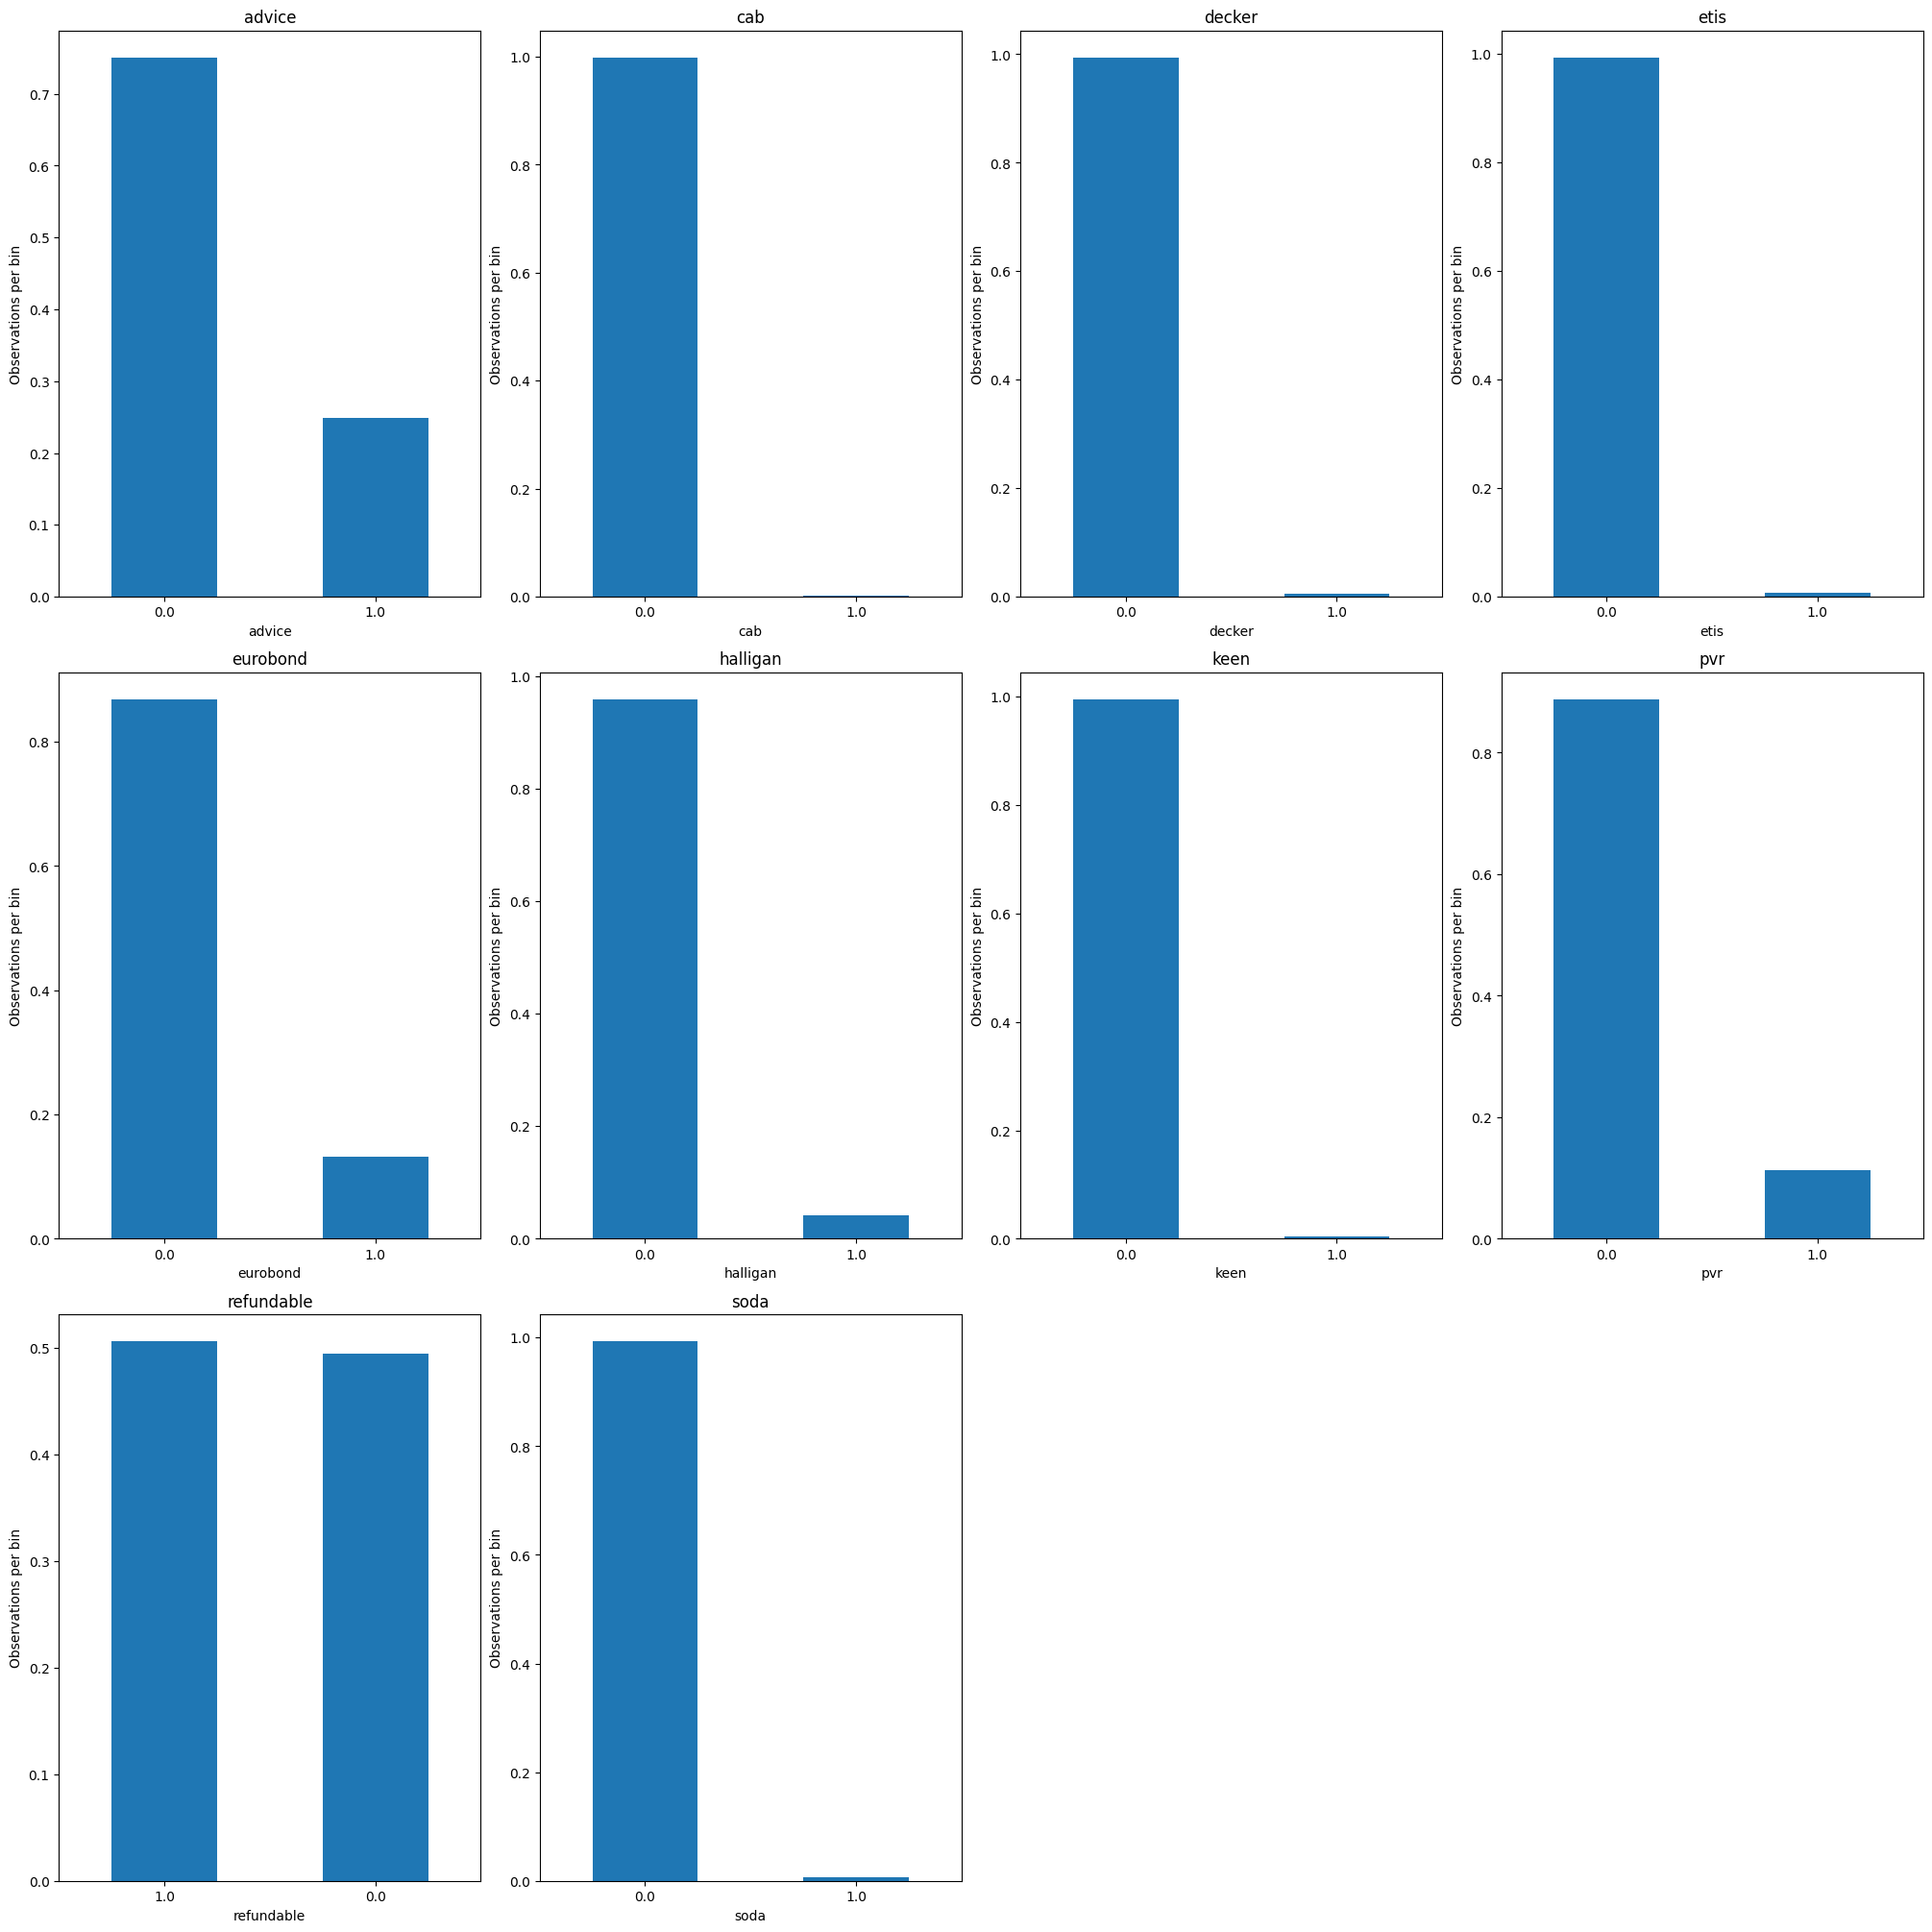

In [96]:
# Let's plot binarized variables:

variables = data_t.columns.to_list()

plt.figure(figsize=(20, 20), constrained_layout=True)

for i in range(10):

    # location in figure
    ax = plt.subplot(3, 4, i + 1)

    # variable to plot
    var = variables[i]

    # determine proportion of observations per bin
    t = data_t[var].value_counts(normalize=True)
    t.plot.bar(ax=ax)

    plt.xticks(rotation=0)
    plt.ylabel("Observations per bin")

    # add variable name as title
    ax.set_title(var)

plt.show()